# 🤖 PART 2: DEEP LEARNING OPTIMIZATION
---
Collaborators:
- Amy Zhang
- ChatGPT
---
🎯 Goal:
Run Bayesian hyperparameter optimization on an RNN model and evaluate performance.



# 1. Import Libraries and Datasets

In [1]:
# 📊 Data manipulation
import pandas as pd
import numpy as np

# 📈 Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# 📁 File operations
import os

# 🔧 Utilities
import operator
from numpy import unique

# 🤖 Deep learning (Keras via TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 📂 Data splitting
from sklearn.model_selection import train_test_split

# 🎲 Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
merged_df = pd.read_csv('weather_pleasant_merged_cleaned.csv')

# 2. Sort & Slide: Build the Sequence for RNN

#### What this code does:
- Loops through each weather station’s data
- Creates sliding windows of 7 days of weather data
- Uses the label of the 8th day as the prediction target
- Collects all sequences and targets into arrays X (inputs) and y (labels)

In [4]:
sequence_length = 7  # Number of days the model will "look back"
X = []
y = []

# Define your features for the model
feature_cols = ['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
                'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min']

# Loop through each unique weather station
# For each, we'll build sequences of 7 days of weather data and the label for the following day
for station in merged_df['weatherstation'].unique():
    # Create a mini-dataframe with only this station's data
    df_station = merged_df[merged_df['weatherstation'] == station]

    # Extract the features and labels as NumPy arrays
    features = df_station[feature_cols].values
    labels = df_station['pleasant_weather'].values

    # Slide a window of size `sequence_length` over the data
    # For each position, grab the sequence and the label of the *next* day
    for i in range(len(df_station) - sequence_length):
        X.append(features[i:i + sequence_length])          # Input: 7 consecutive days of features
        y.append(labels[i + sequence_length])              # Target: pleasant/unpleasant label for the day after

# Convert the final lists into NumPy arrays for model input
X = np.array(X)
y = np.array(y)


# 3. Data Preparation: Temporal Train-Test Split & Feature Scaling


In [5]:
### Split
# Split WITHOUT shuffling — preserve temporal order
split_index = int(len(X) * 0.8)  # 80% train, 20% test

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


In [6]:
### Scale
from sklearn.preprocessing import StandardScaler

# Reshape to 2D (samples × features) to fit the scaler
X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)

# Use the same scaler for test data
X_test_scaled = scaler.transform(X_test_2d)

# Reshape back to 3D (samples × timesteps × features)
X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)


# 5. Install Keras Tuner

In [7]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.9 MB/s eta 0:00:00


# 6. Build the Model & Search Space

| **Component**       | **Hyperparameter Type** | **Being Tuned?** | **Notes**             |
| ------------------- | ----------------------- | ---------------- | --------------------- |
| `units` (LSTM)      | Integer range           | ✅ Yes            | Memory capacity       |
| `dropout`           | Float range             | ✅ Yes            | Regularization        |
| `learning_rate`     | Discrete choice         | ✅ Yes            | Optimization          |
| `Dense(1, sigmoid)` | Fixed                   | ❌ No             | Known binary target   |
| `loss`, `metrics`   | Fixed                   | ❌ No             | Binary classification |


In [8]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    model = keras.Sequential()

    # LSTM layer
    model.add(layers.LSTM(
        units=hp.Int('units', min_value=32, max_value=256, step=32),
        return_sequences=False,  # only one layer for now
        input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])
    ))

    # Dropout for regularization
    model.add(layers.Dropout(
        rate=hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    ))

    # Output layer for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-4, 1e-3, 1e-2])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# 7. Run the Tuner

In [9]:
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=15,
    executions_per_trial=1,
    overwrite=True,
    directory='bayes_tuner',
    project_name='pleasantness_lstm'
)

tuner.search(
    X_train_scaled, y_train,
    epochs=10,  # Keep small at first
    validation_split=0.2,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=2)]
)


Trial 15 Complete [00h 02m 38s]
val_accuracy: 0.8547689914703369

Best val_accuracy So Far: 0.855640709400177
Total elapsed time: 02h 12m 12s


In [10]:
best_model = tuner.get_best_models(num_models=1)[0]


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# 8. Evaluate

Overall accuracy of the model is ~94%.
* (The "accuracy: 0.9690" in the evaluation output is the running accuracy at the last batch or part of the verbose output, not the full test set accuracy)

In [11]:
### Evaluate on a Test Set

test_loss, test_accuracy = best_model.evaluate(X_test_scaled, y_test)
print(f"🧪 Test Accuracy: {test_accuracy:.3f}")


2151/2151 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9690 - loss: 0.0643
🧪 Test Accuracy: 0.942


In [12]:
### Retrieve Best Hyperparameters

best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for param in best_hps.values:
    print(f"  {param}: {best_hps.get(param)}")


Best hyperparameters:
  units: 96
  dropout: 0.4
  learning_rate: 0.001


2151/2151 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


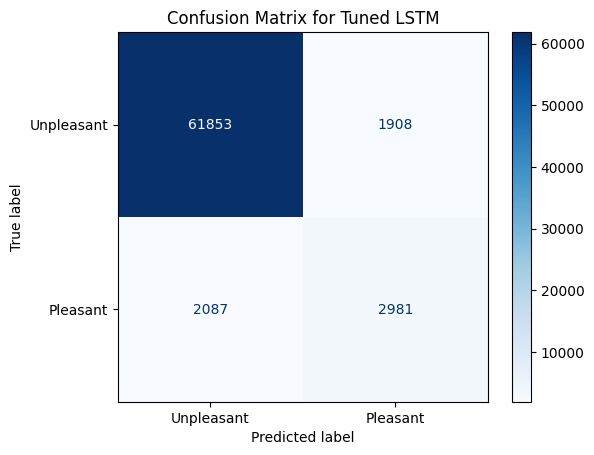

Classification Report:

              precision    recall  f1-score   support

  Unpleasant       0.97      0.97      0.97     63761
    Pleasant       0.61      0.59      0.60      5068

    accuracy                           0.94     68829
   macro avg       0.79      0.78      0.78     68829
weighted avg       0.94      0.94      0.94     68829



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get model predictions
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert probabilities to binary labels

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unpleasant', 'Pleasant'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Tuned LSTM")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Unpleasant', 'Pleasant']))


2151/2151 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


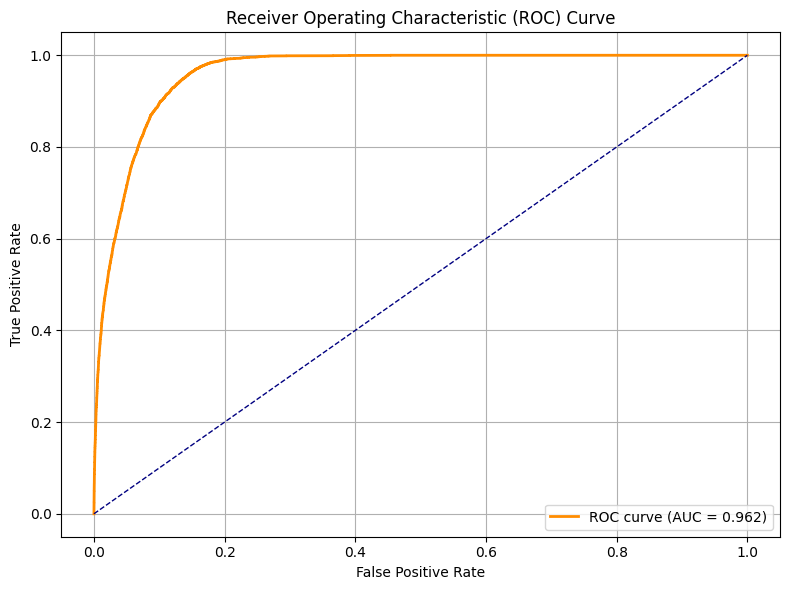

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = best_model.predict(X_test_scaled).flatten()

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
